# Modelling v3 — EKF + Newton Raphson (Sesuai Paper Fahmy et al. 2025)

Implementasi tepat sesuai paper:
- EKF per-timestep dengan state `x = [x1, x2]` = `[cycle_life, V_discharge]`
- Matriks sistem dari Eq. 5–18 paper
- Output EKF = initial guess cycle life → Newton Raphson
- Print detail perhitungan untuk laporan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle, os, warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler

%matplotlib inline

In [2]:
from config_v1 import (
    OUTPUT_DIR, EKF_P0, EKF_R, EKF_Q,
    BATTERY_Q_NOMINAL, BATTERY_RO, BATTERY_R, BATTERY_C,
    SAMPLING_TIME, NR_TOL, NR_MAX_ITER
)

OUTPUT_DIR_V3 = OUTPUT_DIR.replace('v1', 'v3')
EOL_THRESHOLD = 0.88

ekf_params = {
    'Q_nom': BATTERY_Q_NOMINAL,
    'R_bat': BATTERY_R,
    'C_bat': BATTERY_C,
    'Ro':    BATTERY_RO,
    'ts':    SAMPLING_TIME,
    'P0':    EKF_P0,
    'Rw':    EKF_Q,
    'Rv':    EKF_R,
}

print('=== PARAMETER SISTEM (Table 1 & 2 Paper) ===')
print(f'  Nominal capacity  Q  = {BATTERY_Q_NOMINAL} Ah')
print(f'  Internal resist.  Ro = {BATTERY_RO} Ω')
print(f'  Battery resist.   R  = {BATTERY_R} Ω')
print(f'  Battery capac.    C  = {BATTERY_C} F')
print(f'  Sampling time     ts = {SAMPLING_TIME} s')
print(f'  P0 (init cov)        = {EKF_P0}')
print(f'  Rw (process noise)   = {EKF_Q}')
print(f'  Rv (meas. noise)  R  = {EKF_R}')
print(f'  EOL threshold        = {EOL_THRESHOLD} Ah  (80% × {BATTERY_Q_NOMINAL})')

=== PARAMETER SISTEM (Table 1 & 2 Paper) ===
  Nominal capacity  Q  = 1.1 Ah
  Internal resist.  Ro = 0.017 Ω
  Battery resist.   R  = 0.017 Ω
  Battery capac.    C  = 0.1 F
  Sampling time     ts = 1.0 s
  P0 (init cov)        = [2.0, 0.0]
  Rw (process noise)   = [0.8, 0.2]
  Rv (meas. noise)  R  = 0.01
  EOL threshold        = 0.88 Ah  (80% × 1.1)


## 1. Load Data

In [3]:
with open(os.path.join(OUTPUT_DIR, 'preprocessed_v1.pkl'), 'rb') as f:
    data = pickle.load(f)
train_cells = data['train']
val_cells   = data['val']
test_cells  = data['test']
print(f'Train: {len(train_cells)} | Val: {len(val_cells)} | Test: {len(test_cells)}')

Train: 45 | Val: 43 | Test: 45


## 2. Matriks Sistem EKF (Eq. 9–18 Paper)

State: `x = [x1, x2]` = `[cycle_life, V_discharge]`  
Input: `u` = current (A)  
Output: `y` = terminal voltage (V)

In [4]:
Q_nom = ekf_params['Q_nom']
R_bat = ekf_params['R_bat']
C_bat = ekf_params['C_bat']
Ro    = ekf_params['Ro']
ts    = ekf_params['ts']

# Continuous matrices (Eq. 9-12)
Ak = np.array([[0,              0          ],
               [0, -1/(R_bat*C_bat)        ]])
Bk = np.array([[1/Q_nom],
               [1/C_bat]])
Ck = np.array([[1, 1]])
Dk = np.array([[Ro]])

# Discretized matrices (Eq. 13-18)
Ad = np.eye(2) + ts * Ak
Bd = ts * Bk
Cd = Ck
Dd = Dk

print('=== MATRIKS SISTEM KONTINYU ===')
print(f'Ak (Eq.9) = [[0, 0], [0, -1/(R*C)]]')
print(f'         = [[0, 0], [0, -1/({R_bat}×{C_bat})]]')
print(f'         = {Ak.tolist()}')
print()
print(f'Bk (Eq.10) = [[1/Q], [1/C]]')
print(f'          = [[1/{Q_nom}], [1/{C_bat}]]')
print(f'          = {Bk.flatten().tolist()}')
print()
print(f'Ck (Eq.11) = [1, 1]  → {Ck.tolist()}')
print(f'Dk (Eq.12) = Ro = {Ro}  → {Dk.tolist()}')
print()
print('=== MATRIKS DISKRIT (ts={ts}s) ===')
print(f'Ad (Eq.14) = I + ts×Ak')
print(f'         = {np.eye(2).tolist()} + {ts}×{Ak.tolist()}')
print(f'         = {Ad.tolist()}')
print()
print(f'Bd (Eq.15) = ts×Bk = {ts}×{Bk.flatten().tolist()} = {Bd.flatten().tolist()}')

=== MATRIKS SISTEM KONTINYU ===
Ak (Eq.9) = [[0, 0], [0, -1/(R*C)]]
         = [[0, 0], [0, -1/(0.017×0.1)]]
         = [[0.0, 0.0], [0.0, -588.2352941176471]]

Bk (Eq.10) = [[1/Q], [1/C]]
          = [[1/1.1], [1/0.1]]
          = [0.9090909090909091, 10.0]

Ck (Eq.11) = [1, 1]  → [[1, 1]]
Dk (Eq.12) = Ro = 0.017  → [[0.017]]

=== MATRIKS DISKRIT (ts={ts}s) ===
Ad (Eq.14) = I + ts×Ak
         = [[1.0, 0.0], [0.0, 1.0]] + 1.0×[[0.0, 0.0], [0.0, -588.2352941176471]]
         = [[1.0, 0.0], [0.0, -587.2352941176471]]

Bd (Eq.15) = ts×Bk = 1.0×[0.9090909090909091, 10.0] = [0.9090909090909091, 10.0]


## 3. Fungsi EKF Per-Timestep (Eq. 19–24 Paper)

Sesuai Fig. 3 paper: input EKF = **Discharge Voltage, Current, Temperature, Cycle life**  
Output EKF = **Initial Guess Cycle Life** → masuk Newton Raphson

In [5]:
def run_ekf(cell, ekf_params, verbose=False, verbose_cycles=None):
    Q_nom = ekf_params['Q_nom']
    R_bat = ekf_params['R_bat']
    C_bat = ekf_params['C_bat']
    Ro    = ekf_params['Ro']
    ts    = ekf_params['ts']

    P0 = np.diag(ekf_params['P0'])
    Rw = np.diag(ekf_params['Rw'])
    Rv = np.array([[ekf_params['Rv']]])

    Ak = np.array([[0, 0], [0, -1/(R_bat*C_bat)]])
    Bk = np.array([[1/Q_nom], [1/C_bat]])
    Ck = np.array([[1, 1]])
    Dk = np.array([[Ro]])
    Ad = np.eye(2) + ts * Ak
    Bd = ts * Bk
    Cd = Ck
    Dd = Dk

    cycles = cell['cycles']
    if len(cycles) == 0:
        return np.nan, []

    V0 = cycles[0]['V']
    x  = np.array([0.0, V0[0] if len(V0) > 0 else 3.3])
    P  = P0.copy()

    if verbose:
        print(f'  INIT  x0 = [x1={x[0]:.4f}, x2={x[1]:.4f}]')
        print(f'  INIT  P0 = {P.tolist()}')

    x1_per_cycle = []

    for c_idx, cycle_data in enumerate(cycles):
        V = cycle_data['V']
        I = cycle_data['I']
        n = len(V)
        if n < 5:
            continue

        x[0] = float(c_idx + 1)
        do_print = verbose and (verbose_cycles is None or c_idx in verbose_cycles)

        if do_print:
            print(f'\n  ── CYCLE {c_idx+1} (k=0..{n-1}) ──')

        for k in range(n):
            u      = I[k]
            y_meas = V[k]

            # PREDICT (Eq. 19-20)
            x_pred = Ad @ x + Bd.flatten() * u
            P_pred = Ad @ P @ Ad.T + Rw

            # KALMAN GAIN (Eq. 21)
            S = Cd @ P_pred @ Cd.T + Rv
            K = P_pred @ Cd.T / S[0, 0]

            # INNOVATION
            y_hat = (Cd @ x_pred)[0] + Dd[0, 0] * u
            innov = y_meas - y_hat

            # UPDATE (Eq. 22-23)
            x = x_pred + K.flatten() * innov
            P = (np.eye(2) - K @ Cd) @ P_pred

            if do_print and k < 3:
                print(f'    k={k}: u={u:.4f}A  y_meas={y_meas:.4f}V')
                print(f'      Predict (Eq.19): x_pred = Ad@x + Bd*u')
                print(f'        = {Ad.tolist()} @ [{x[0]:.4f},{x[1]:.4f}] + {Bd.flatten().tolist()} * {u:.4f}')
                print(f'        x_pred = [{x_pred[0]:.4f}, {x_pred[1]:.4f}]')
                print(f'      Kalman Gain (Eq.21): K = P_pred@Cd.T / (Cd@P_pred@Cd.T + Rv)')
                print(f'        S = {S[0,0]:.6f},  K = [{K[0,0]:.6f}, {K[1,0]:.6f}]')
                print(f'      Innovation: y_hat={y_hat:.4f}V,  innov={innov:.4f}V')
                print(f'      Update (Eq.22): x = x_pred + K*innov')
                print(f'        = [{x_pred[0]:.4f},{x_pred[1]:.4f}] + [{K[0,0]:.4f},{K[1,0]:.4f}]*{innov:.4f}')
                print(f'        x_updated = [{x[0]:.4f}, {x[1]:.4f}]')

        x1_per_cycle.append(x[0])

        if do_print:
            print(f'  End cycle {c_idx+1}: x1 (cycle life estimate) = {x[0]:.4f}')

    return x[0], x1_per_cycle


print('Fungsi run_ekf() siap.')

Fungsi run_ekf() siap.


## 4. Newton Raphson (Eq. 25 Paper)

In [6]:
def fit_degradation_model(Q):
    n = len(Q)
    cycles = np.arange(1, n + 1, dtype=float)
    coeffs = np.polyfit(cycles, Q, deg=2)
    return coeffs


def newton_raphson_eol(coeffs, eol_threshold, x0, tol=1e-6, max_iter=100, verbose=False):
    a, b, c = coeffs
    f  = lambda x: a*x**2 + b*x + c - eol_threshold
    df = lambda x: 2*a*x + b

    if verbose:
        print(f'  Model degradasi: f(x) = {a:.6e}·x² + {b:.6e}·x + {c:.6f} - {eol_threshold}')
        print(f'  f(x) = {a:.4e}·x² + ({b:.4e})·x + {c:.4f} - {eol_threshold}')
        print(f"  f'(x) = 2·{a:.4e}·x + {b:.4e}")
        print(f'  x0 awal (dari EKF) = {x0:.4f}')
        print(f'  {'Iter':>5} | {'x_i':>12} | {'f(x_i)':>14} | {"f\'(x_i)":>14} | {"x_i+1":>12} | {"|\'delta x|":>12}')
        print(f'  {"-"*80}')

    x = float(x0)
    for i in range(max_iter):
        fx  = f(x)
        dfx = df(x)
        if abs(dfx) < 1e-12:
            break
        x_new   = x - fx / dfx
        delta_x = abs(x_new - x)

        if verbose and i < 10:
            print(f'  {i:>5} | {x:>12.4f} | {fx:>14.6f} | {dfx:>14.6f} | {x_new:>12.4f} | {delta_x:>12.8f}')

        if delta_x < tol:
            if verbose:
                print(f'  Konvergen pada iterasi {i+1}: x* = {x_new:.4f} (|delta| < {tol})')
            return max(x_new, 1.0)
        x = x_new

    return max(x, 1.0)


def predict_cycle_life_v3(cell, ekf_params, eol_threshold, tol, max_iter, verbose=False):
    Q = cell['summary']['QDischarge']
    if len(Q) < 10:
        return np.nan

    # Step 1: EKF → initial guess
    x1_final, x1_per_cycle = run_ekf(cell, ekf_params, verbose=verbose,
                                      verbose_cycles=[0] if verbose else None)
    if np.isnan(x1_final):
        return np.nan

    x0_nr = max(x1_final * 1.2, len(Q) * 1.1)

    if verbose:
        print(f'\n  EKF final x1 = {x1_final:.4f}')
        print(f'  x0 NR = max({x1_final:.4f}×1.2, {len(Q)}×1.1) = {x0_nr:.4f}')
        print()

    # Step 2: NR pada polynomial fit QDischarge
    coeffs    = fit_degradation_model(Q)
    predicted = newton_raphson_eol(coeffs, eol_threshold, x0_nr, tol, max_iter, verbose=verbose)
    predicted = np.clip(predicted, 50, 5000)
    return predicted


print('Fungsi Newton Raphson siap.')

Fungsi Newton Raphson siap.


## 5. Demo Perhitungan Detail — 1 Cell (Untuk Laporan)

Print step-by-step EKF dan Newton Raphson sesuai persamaan paper.

In [7]:
sample = test_cells[0]
print('=' * 70)
print(f'CELL ID: {sample["cell_id"]}  |  Actual Cycle Life: {sample["cycle_life"]}')
print(f'Jumlah cycle observasi: {len(sample["cycles"])}')
print(f'Jumlah timestep cycle pertama: {len(sample["cycles"][0]["V"])}')
print('=' * 70)

print('\n>>> FASE EKF (Eq. 19-24) — 3 timestep pertama, cycle 1 & 2:')
pred_demo = predict_cycle_life_v3(
    sample, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER,
    verbose=True
)
print(f'\n>>> HASIL: Predicted Cycle Life = {pred_demo:.2f}')
print(f'>>> Actual Cycle Life          = {sample["cycle_life"]}')
print(f'>>> Error                      = {abs(pred_demo - sample["cycle_life"]):.2f} cycles ({abs(pred_demo - sample["cycle_life"])/sample["cycle_life"]*100:.2f}%)')

CELL ID: b1_c41  |  Actual Cycle Life: 1051.0
Jumlah cycle observasi: 1049
Jumlah timestep cycle pertama: 1104

>>> FASE EKF (Eq. 19-24) — 3 timestep pertama, cycle 1 & 2:
  INIT  x0 = [x1=0.0000, x2=2.0161]
  INIT  P0 = [[2.0, 0.0], [0.0, 0.0]]

  ── CYCLE 1 (k=0..1103) ──
    k=0: u=0.0000A  y_meas=2.0161V
      Predict (Eq.19): x_pred = Ad@x + Bd*u
        = [[1.0, 0.0], [0.0, -587.2352941176471]] @ [1103.2609,-1105.1815] + [0.9090909090909091, 10.0] * 0.0000
        x_pred = [1.0000, -1183.9144]
      Kalman Gain (Eq.21): K = P_pred@Cd.T / (Cd@P_pred@Cd.T + Rv)
        S = 3.010000,  K = [0.930233, 0.066445]
      Innovation: y_hat=-1182.9144V,  innov=1184.9305V
      Update (Eq.22): x = x_pred + K*innov
        = [1.0000,-1183.9144] + [0.9302,0.0664]*1184.9305
        x_updated = [1103.2609, -1105.1815]
    k=1: u=0.3996A  y_meas=2.0347V
      Predict (Eq.19): x_pred = Ad@x + Bd*u
        = [[1.0, 0.0], [0.0, -587.2352941176471]] @ [-5.7646,7.8932] + [0.9090909090909091, 10.0] * 0

## 6. Prediksi Semua Test Cells

In [8]:
actual_v3    = []
predicted_v3 = []

print(f'{'Cell':>6} | {'Actual':>8} | {'Predicted':>10} | {'Error':>8} | {'%Err':>7}')
print('-' * 52)

for i, cell in enumerate(test_cells):
    pred = predict_cycle_life_v3(cell, ekf_params, EOL_THRESHOLD, NR_TOL, NR_MAX_ITER)
    actual_v3.append(cell['cycle_life'])
    predicted_v3.append(pred)
    if not np.isnan(pred):
        err  = abs(pred - cell['cycle_life'])
        pct  = err / cell['cycle_life'] * 100
        print(f'{i+1:>6} | {cell["cycle_life"]:>8.0f} | {pred:>10.2f} | {err:>8.2f} | {pct:>6.2f}%')
    else:
        print(f'{i+1:>6} | {cell["cycle_life"]:>8.0f} | {"NaN":>10} |    -    |    -')

actual_v3    = np.array(actual_v3)
predicted_v3 = np.array(predicted_v3)

  Cell |   Actual |  Predicted |    Error |    %Err
----------------------------------------------------
     1 |     1051 |    1137.06 |    86.06 |   8.19%
     2 |      702 |     733.68 |    31.68 |   4.51%
     3 |      651 |     696.10 |    45.10 |   6.93%
     4 |      616 |     639.49 |    23.49 |   3.81%
     5 |      599 |     628.08 |    29.08 |   4.86%
     6 |     1009 |    1158.48 |   149.48 |  14.82%
     7 |     1063 |    1191.28 |   128.28 |  12.07%
     8 |     1267 |    1367.39 |   100.39 |   7.92%
     9 |     1115 |    1242.36 |   127.36 |  11.42%
    10 |     1048 |    1140.97 |    92.97 |   8.87%
    11 |      828 |     932.76 |   104.76 |  12.65%
    12 |      667 |     695.62 |    28.62 |   4.29%
    13 |     1836 |    2005.09 |   169.09 |   9.21%
    14 |      828 |     947.98 |   119.98 |  14.49%
    15 |     1039 |    1168.20 |   129.20 |  12.44%
    16 |     1078 |    1190.96 |   112.96 |  10.48%
    17 |      817 |     899.81 |    82.81 |  10.14%
    18 |   

## 7. Linear Regression Baseline (ElasticNet)

In [9]:
def extract_features(cells):
    feats, targets = [], []
    for cell in cells:
        q  = cell['summary']['QDischarge']
        ir = cell['summary']['IR']
        if len(q) < 100:
            continue
        feats.append([
            np.mean(q[1:101]),
            np.min(q[1:101]),
            np.var(q[1:101]),
            q[99] - q[9],
            np.mean(ir[1:101]),
            np.log(np.var(q[1:101]) + 1e-10),
        ])
        targets.append(cell['cycle_life'])
    return np.array(feats), np.array(targets)

X_train, y_train = extract_features(train_cells)
X_val,   y_val   = extract_features(val_cells)
X_test,  y_test  = extract_features(test_cells)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

lr_model = ElasticNetCV(cv=5, max_iter=10000, random_state=42)
lr_model.fit(np.vstack([X_train, X_val]), np.concatenate([y_train, y_val]))
predicted_lr = lr_model.predict(X_test)
actual_lr    = y_test
print(f'ElasticNet alpha={lr_model.alpha_:.4f}, l1_ratio={lr_model.l1_ratio_:.4f}')

ElasticNet alpha=2.3643, l1_ratio=0.5000


## 8. Evaluasi RMSE & Average Percentage Error (Eq. 1–2 Paper)

In [10]:
def rmse(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.sqrt(np.mean((actual[mask] - predicted[mask]) ** 2))

def avg_pct_error(actual, predicted):
    mask = ~np.isnan(predicted)
    return np.mean(np.abs(actual[mask] - predicted[mask]) / actual[mask]) * 100

rmse_v3 = rmse(actual_v3, predicted_v3)
ape_v3  = avg_pct_error(actual_v3, predicted_v3)
rmse_lr = rmse(actual_lr, predicted_lr)
ape_lr  = avg_pct_error(actual_lr, predicted_lr)

mask = ~np.isnan(predicted_v3)
N    = mask.sum()
print('=== RMSE (Eq. 1) ===')
print(f'  RMSE = sqrt( (1/N) * sum( (xi - x̂i)² ) )')
print(f'       = sqrt( (1/{N}) * {np.sum((actual_v3[mask]-predicted_v3[mask])**2):.2f} )')
print(f'       = {rmse_v3:.4f} cycles')
print()
print('=== Avg % Error (Eq. 2) ===')
print(f'  %AvgErr = (1/N) * sum( |xi - x̂i| / xi ) × 100')
print(f'          = (1/{N}) * {np.sum(np.abs(actual_v3[mask]-predicted_v3[mask])/actual_v3[mask])*100:.4f}')
print(f'          = {ape_v3:.4f}%')
print()
print('=' * 60)
print(f'{'Method':<32} {'RMSE':>10} {'Avg%Err':>10}')
print('=' * 60)
print(f'{'EKF + NR v3 (paper impl.)':<32} {rmse_v3:>10.4f} {ape_v3:>9.4f}%')
print(f'{'Linear Regression':<32} {rmse_lr:>10.4f} {ape_lr:>9.4f}%')
print('=' * 60)
print(f'\nPaper target EKF+NR → RMSE: 10.93  | Avg%Err: 3.26%')
print(f'Paper target LinReg → RMSE: 211.6  | Avg%Err: 9.98%')

=== RMSE (Eq. 1) ===
  RMSE = sqrt( (1/N) * sum( (xi - x̂i)² ) )
       = sqrt( (1/45) * 644426.43 )
       = 119.6687 cycles

=== Avg % Error (Eq. 2) ===
  %AvgErr = (1/N) * sum( |xi - x̂i| / xi ) × 100
          = (1/45) * 484.7666
          = 10.7726%

Method                                 RMSE    Avg%Err
EKF + NR v3 (paper impl.)          119.6687   10.7726%
Linear Regression                  307.7389   19.3970%

Paper target EKF+NR → RMSE: 10.93  | Avg%Err: 3.26%
Paper target LinReg → RMSE: 211.6  | Avg%Err: 9.98%


## 9. Visualisasi (Fig. 4, 5, 6 Paper)

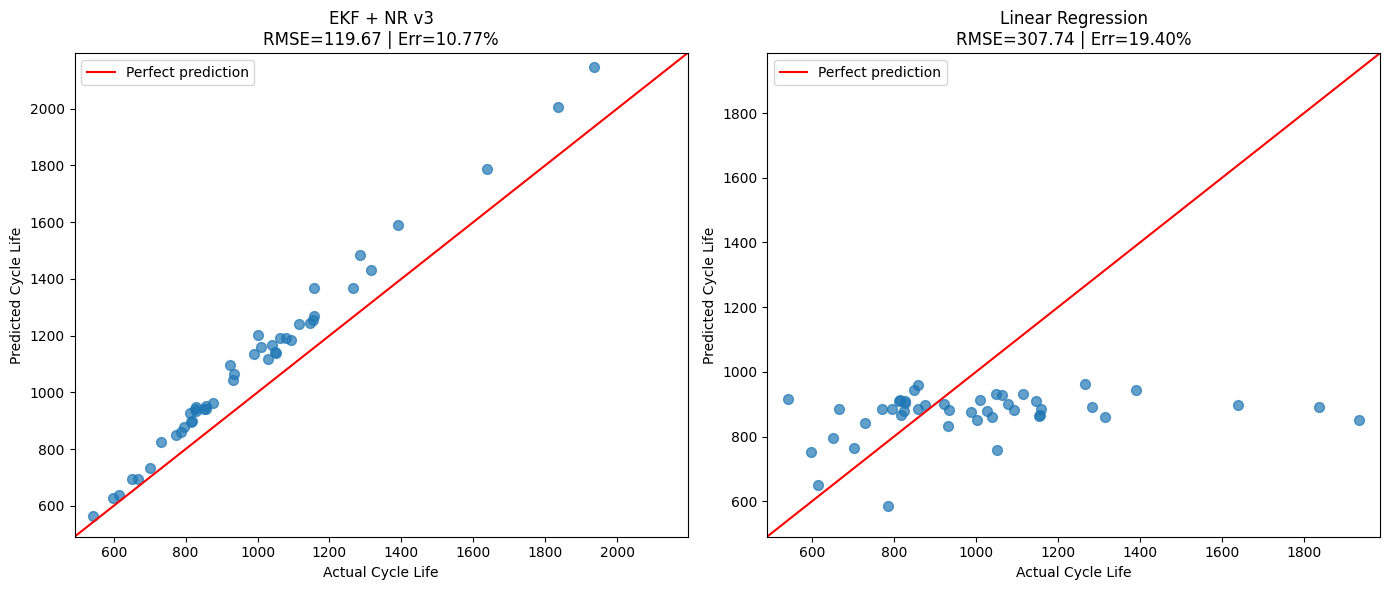

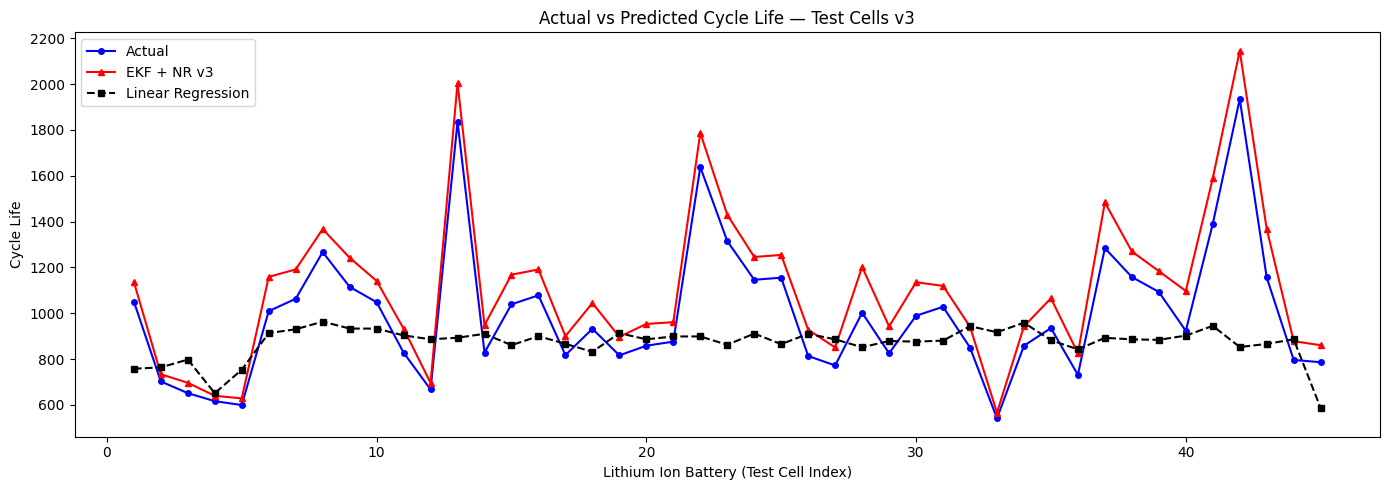

In [11]:
os.makedirs(os.path.join(OUTPUT_DIR_V3, 'figures'), exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
pairs = [
    (actual_v3,  predicted_v3, f'EKF + NR v3\nRMSE={rmse_v3:.2f} | Err={ape_v3:.2f}%'),
    (actual_lr,  predicted_lr, f'Linear Regression\nRMSE={rmse_lr:.2f} | Err={ape_lr:.2f}%'),
]
for ax, (actual, predicted, title) in zip(axes, pairs):
    mask = ~np.isnan(predicted)
    a, p = actual[mask], predicted[mask]
    lims = [min(a.min(), p.min()) - 50, max(a.max(), p.max()) + 50]
    ax.plot(lims, lims, 'r-', linewidth=1.5, label='Perfect prediction')
    ax.scatter(a, p, alpha=0.7, s=50)
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel('Actual Cycle Life')
    ax.set_ylabel('Predicted Cycle Life')
    ax.set_title(title)
    ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V3, 'figures', 'actual_vs_predicted_v3.png'), dpi=150)
plt.show()

x_idx = np.arange(1, len(actual_v3) + 1)
plt.figure(figsize=(14, 5))
plt.plot(x_idx, actual_v3,    'b-o', markersize=4, label='Actual')
plt.plot(x_idx, predicted_v3, 'r-^', markersize=4, label='EKF + NR v3')
plt.plot(x_idx, predicted_lr, 'k--s', markersize=4, label='Linear Regression')
plt.xlabel('Lithium Ion Battery (Test Cell Index)')
plt.ylabel('Cycle Life')
plt.title('Actual vs Predicted Cycle Life — Test Cells v3')
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR_V3, 'figures', 'per_cell_v3.png'), dpi=150)
plt.show()

## 10. Simpan Hasil

In [12]:
os.makedirs(os.path.join(OUTPUT_DIR_V3, 'results'), exist_ok=True)
results = {
    'ekf_nr_v3':         {'actual': actual_v3.tolist(), 'predicted': predicted_v3.tolist(), 'rmse': rmse_v3, 'avg_pct_error': ape_v3},
    'linear_regression': {'actual': actual_lr.tolist(), 'predicted': predicted_lr.tolist(), 'rmse': rmse_lr, 'avg_pct_error': ape_lr},
}
with open(os.path.join(OUTPUT_DIR_V3, 'results', 'results_v3.pkl'), 'wb') as f:
    pickle.dump(results, f)
print(f'Saved to {OUTPUT_DIR_V3}')

Saved to ../../outputs/v3
